In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
DATA_DIR  = "../../flatten/processed-data"
DATA_FILE = f"{DATA_DIR}/20251209-s288c-annotated-PPI-net.pkl"
nodes     = pd.read_pickle(DATA_FILE)

In [45]:
# determine threshold for hubs based on quantile cutoff for degree centrality
cut          = 0.10
threshold    = nodes["degree_centrality"].quantile(1 - cut)

# add a boolean hub column: True if degree_centrality >= threshold, else False
nodes["hub"] = nodes["degree_centrality"] >= threshold

cut = 0.10
threshold = nodes["betweenness_centrality"].quantile(1 - cut)
nodes["bottleneck"] = nodes["betweenness_centrality"] >= threshold

In [46]:
has_phospho_flag = (nodes["ptm_gold"].notna())

has_phospho_text = nodes["parsed_PTMs"].str.contains(
    "phospho", case=False, na=False
)

# combine both criteria
nodes["phosphorylated"] = has_phospho_flag | has_phospho_text

* make boxplots of melting temperature for hubs and non-hubs

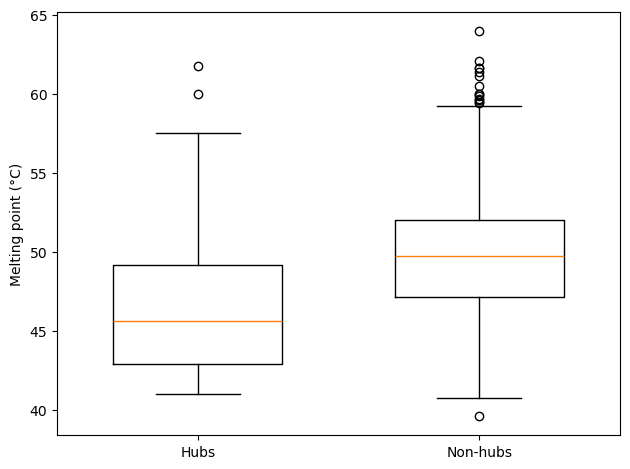

In [47]:
subset = nodes[nodes["meltome-fit-R2"] >= 0.9].copy()

hub_tm = subset.loc[subset["hub"], "meltome-melting-point"].dropna()
nonhub_tm = subset.loc[~subset["hub"], "meltome-melting-point"].dropna()

plt.clf()
plt.boxplot(
    [hub_tm, nonhub_tm],
    positions=[1, 2],      # x positions of the two boxes
    widths=0.6,            # optional, cosmetic
)

plt.xticks([1, 2], ["Hubs", "Non-hubs"])
plt.ylabel("Melting point (°C)")  # or whatever units
plt.tight_layout()

In [48]:
nodes["ptm_gold"]

0                                                     NaN
1       S1005;S102;S1034;S1036;S218;S303;S363;S398;S41...
2       S429;S484;S493;S536;S670;S928;S940;T409;T488;T...
3                                                     NaN
4                                                     NaN
                              ...                        
3922                                                  NaN
3923                                                 S146
3924                                            S327;T257
3925                                   S181;S188;S209;T50
3926                                                  NaN
Name: ptm_gold, Length: 3927, dtype: object

In [49]:
mask = subset["ptm_gold"].isna() | (subset["ptm_gold"] == "NaN")

subset["n_ptm_gold"] = np.where(
    mask,
    0,
    subset["ptm_gold"].str.split(";").str.len()
)

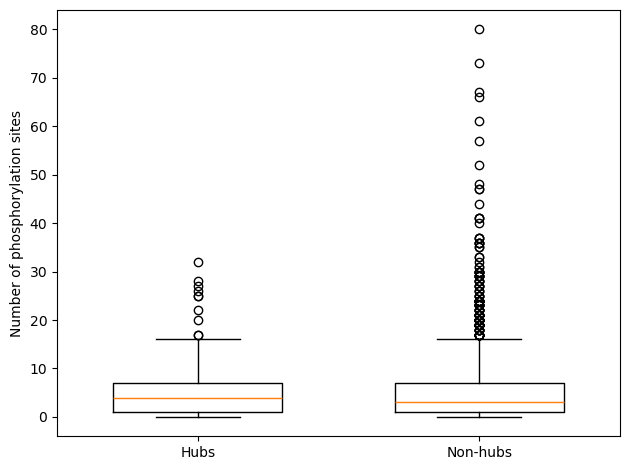

In [50]:
hub_phospho = subset.loc[nodes["hub"], "n_ptm_gold"]
nonhub_phospho = subset.loc[~nodes["hub"], "n_ptm_gold"]

plt.clf()
plt.boxplot(
    [hub_phospho, nonhub_phospho],
    positions=[1, 2],      # x positions of the two boxes
    widths=0.6,            # optional, cosmetic
)

plt.xticks([1, 2], ["Hubs", "Non-hubs"])
plt.ylabel("Number of phosphorylation sites")  # or whatever units
plt.tight_layout()

(array([0.76510523, 0.90699253, 0.9545146 , 0.98167006, 0.9898167 ,
        0.99456891, 0.99592668, 0.99728445, 0.99864223, 1.        ]),
 array([ 0.,  8., 16., 24., 32., 40., 48., 56., 64., 72., 80.]),
 [<matplotlib.patches.Polygon at 0x72471ef98910>])

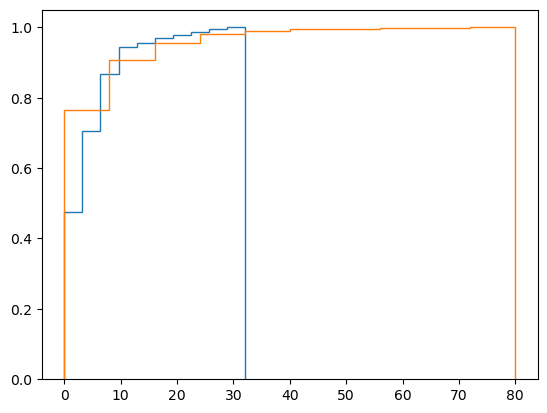

In [51]:
plt.clf()
plt.hist(hub_phospho, label="hubs", density=True, cumulative=True, histtype="step")
plt.hist(nonhub_phospho, label="Non-hubs", density=True, cumulative=True, histtype="step")

ValueError: autodetected range of [nan, nan] is not finite

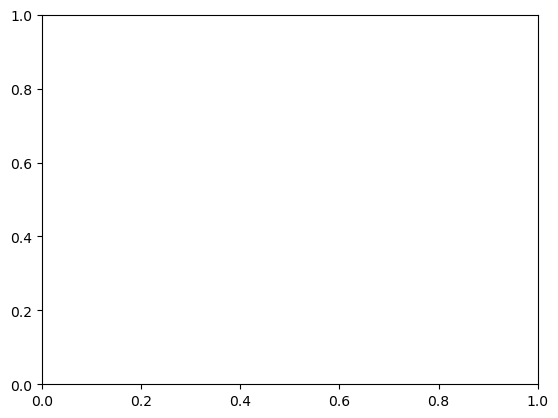

In [52]:
# x, y are 1D arrays, e.g. df["x"], df["y"]
x = subset["meltome-melting-point"]
y = subset["n_ptm_gold"]

plt.clf()
h = plt.hist2d(
    x,
    y,
    bins=50,               # or (nx, ny)
    #range=[[xmin, xmax],
    #       [ymin, ymax]],  # optional
)

plt.colorbar(h[3], label="Counts")  # h[3] is the QuadMesh
plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
